<a href="https://colab.research.google.com/github/reemmohamed2003/Instuction_decoder/blob/main/VAE_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [23]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [24]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [25]:
x_train=np.expand_dims(x_train, -1)
x_test=np.expand_dims(x_test, -1)

In [26]:
print(x_train.shape)

(60000, 28, 28, 1)


##Encoder

##Image
  ↓
Conv
  ↓
Conv
  ↓
Flatten
  ↓
Dense
  ↓
 ┌───────────┐
 ↓           ↓
μ         log_var

##
28 × 28 × 1
      ↓
14 × 14 × 32
      ↓
 7 × 7 × 64
      ↓
Flatten
      ↓
3136
      ↓
Dense(16)
      ↓
 μ , log_var
      ↓
     z

In [27]:
class Encoder(keras.Model):
  def __init__(self, latent_dim):    ##laten_diam=2
    super().__init__()
    self.latent_dim=latent_dim
    self.conv1=layers.Conv2D(32,3,strides=2,activation="relu",padding="same")
    self.conv2=layers.Conv2D(64,3,strides=2,activation="relu",padding="same")
    self.flatten=layers.Flatten()
    self.dense=layers.Dense(16,activation="relu")
    self.mu = layers.Dense(latent_dim)
    self.log_var = layers.Dense(latent_dim)

  def build(self, input_shape):
      # The layers are defined in __init__, Keras will build them on first call.
      # This empty build method explicitly marks the layer as built for Keras.
      super().build(input_shape)

  def call(self,x):
    x=self.conv1(x)
    x=self.conv2(x)
    x=self.flatten(x)
    x=self.dense(x)
    mu=self.mu(x)
    log_var=self.log_var(x)
    return mu,log_var

##Sampling Class

In [28]:
class Sampling(layers.Layer):
  def call(self,inputs):
    mu,log_var=inputs
    epsilon=tf.random.normal(shape=tf.shape(mu))
    sigma=tf.exp(log_var*0.5)
    z=mu+sigma*epsilon
    return z




##Decoder

##
z
↓
Dense
↓
Reshape
↓
Conv2DTranspose
↓
Conv2DTranspose
↓
Reconstructed Image

##    
 z
      ↓
Dense(3136)
      ↓
7 × 7 × 64
      ↓
Conv2DTranspose
      ↓
14 × 14 × 64
      ↓
Conv2DTranspose
      ↓
28 × 28 × 32
      ↓
Conv2DTranspose
      ↓
28 × 28 × 1

In [ ]:
class Decoder(keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.dense =layers.Dense(7*7*64,activation="relu")
        self.reshape=layers.Reshape((7,7,64))
        self.Deconv1=layers.Conv2DTranspose(64,3,strides=2,activation="relu",padding="same")
        self.Deconv2=layers.Conv2DTranspose(32,3,strides=2,activation="relu",padding="same")
        self.output_layer=layers.Conv2D(1,3,activation="sigmoid",padding="same")

    def call(self,z):
        x=self.dense(z)
        x=self.reshape(x)
        x=self.Deconv1(x)
        x=self.Deconv2(x)
        output=self.output_layer(x)
        return output

In [30]:
class VAE(keras.Model):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()

    def call(self, x):

        # Encoder
        mu, log_var = self.encoder(x)

        # Sampling
        z = self.sampling((mu, log_var))

        # Decoder
        reconstruction = self.decoder(z)

        return reconstruction, mu, log_var

##Instantiate the Models

In [37]:
latent_dim = 2

encoder = Encoder(latent_dim)
decoder = Decoder(latent_dim)

vae = VAE(encoder, decoder)

##Reconstruction Loss + KL Loss + Backpropagation

In [38]:
optimizer=keras.optimizers.Adam()

##Training

In [42]:
batch_size = 128
epochs = 10
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(2000).batch(batch_size)

##Forward Pass → Reconstruction Loss → KL Loss → Total Loss → Backpropagation → Update Weight

In [43]:
for epoch in range(epochs):

    for x_batch in train_dataset:

        with tf.GradientTape() as tape:   ##store all calculation steps

            # -------------------------
            # Forward Pass
            # -------------------------

            reconstruction, mu, log_var = vae(x_batch)

            # -------------------------
            # Reconstruction Loss
            # -------------------------   ####  128 images then 128 reconstruction losses then mean  then one reconstruction loss for the batch
            ######اجمع pixel losses داخل كل صورة، وبعد كده خُد متوسط الصور الموجودة في الـ batch.

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        x_batch,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # -------------------------
            # KL Loss
            # -------------------------
            ##   KL=−21​i∑​(1+log(σi2​)−μi2​−σi2​)         log(σ2)=log_var               σ2=elog_var

            kl_loss = -0.5 * tf.reduce_mean(

                tf.reduce_sum(
                    1 + log_var
                    - tf.square(mu)      ##μ2
                    - tf.exp(log_var),
                    axis=1     ## because latent_dim = 2   every image has mu =[z1_mean, z2_mean] ,log_var =[z1_var, z2_var]
                )
            )     ## فإحنا عايزين نجمع الـ KL contributions الخاصة بالـ latent dimensions: KL1​+KL2​




            # -------------------------
            # Total Loss
            # -------------------------
            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        # -------------------------
        # Backpropagation
        # -------------------------

        gradients = tape.gradient(   ##  احسبلي مشتقة الـ total loss بالنسبة لكل trainable variable في الـ VAE
            total_loss,
            vae.trainable_variables
        )

        optimizer.apply_gradients(     ##Updata weights
            zip(
                gradients,
                vae.trainable_variables
            )
        )


    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {total_loss.numpy():.4f} "
        f"- Recon: {reconstruction_loss.numpy():.4f} "
        f"- KL: {kl_loss.numpy():.4f}"
    )

Epoch 1/10 - Loss: 158.9544 - Recon: 152.7746 - KL: 6.1798
Epoch 2/10 - Loss: 164.4706 - Recon: 158.3685 - KL: 6.1021
Epoch 3/10 - Loss: 154.9193 - Recon: 148.4977 - KL: 6.4215
Epoch 4/10 - Loss: 153.3569 - Recon: 146.9602 - KL: 6.3967
Epoch 5/10 - Loss: 152.8142 - Recon: 146.4499 - KL: 6.3642
Epoch 6/10 - Loss: 151.9498 - Recon: 145.5987 - KL: 6.3511
Epoch 7/10 - Loss: 150.3853 - Recon: 143.9758 - KL: 6.4095
Epoch 8/10 - Loss: 147.5140 - Recon: 141.1644 - KL: 6.3496
Epoch 9/10 - Loss: 151.7468 - Recon: 145.2557 - KL: 6.4911
Epoch 10/10 - Loss: 144.7802 - Recon: 138.0899 - KL: 6.6903


In [44]:
reconstruction, mu, log_var = vae(x_batch)

In [45]:
total_loss

<tf.Tensor: shape=(), dtype=float32, numpy=144.78021240234375>

In [47]:
Encoder
Decoder


__main__.Decoder

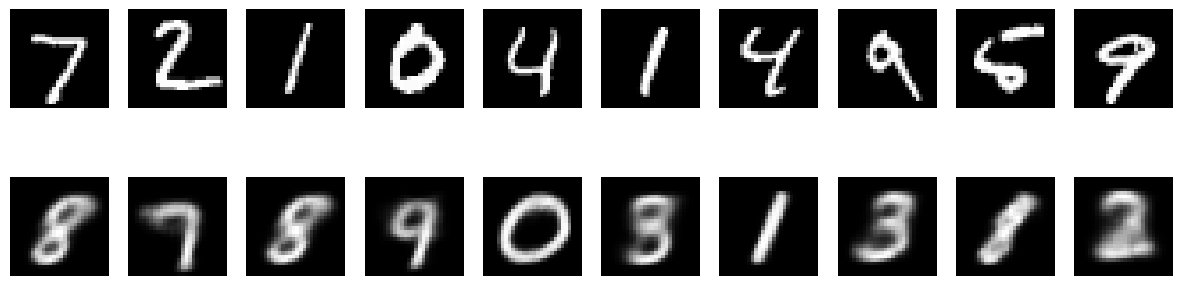

In [48]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(
        reconstruction[i].numpy().squeeze(),
        cmap="gray"
    )
    plt.axis("off")

plt.show()

In [49]:
z = np.random.normal(
    size=(16, latent_dim)
).astype("float32")

generated = decoder(z)

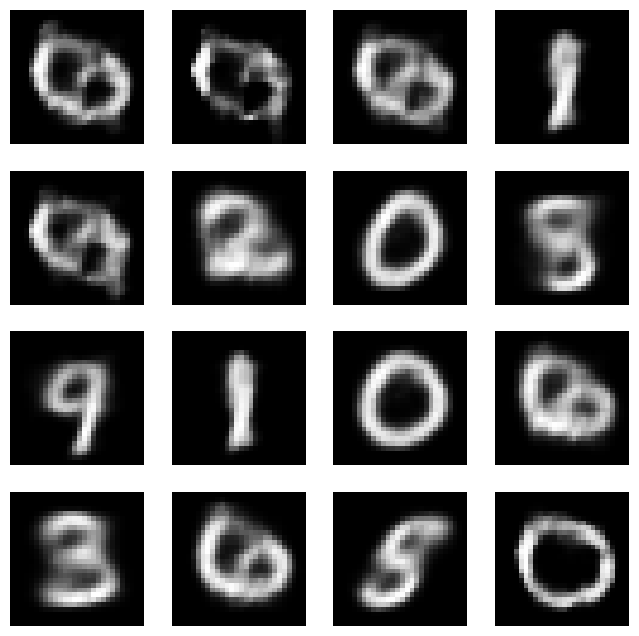

In [50]:
plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        generated[i].numpy().squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.show()